### Assignment 3

Given a bank customer, build a neural network-based classifier that can determine whether
they will leave or not in the next 6 months.
Dataset Description: The case study is from an open-source dataset from Kaggle.
The dataset contains 10,000 sample points with 14 distinct features such as
CustomerId, CreditScore, Geography, Gender, Age, Tenure, Balance, etc.

Link to the Kaggle project:
https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling

Perform following steps:

1. Read the dataset.
2. Distinguish the feature and target set and divide the data set into training and test sets.
3. Normalize the train and test data.
4. Initialize and build the model. Identify the points of improvement and implement the same.
5. Print the accuracy score and confusion matrix 

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

In [4]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


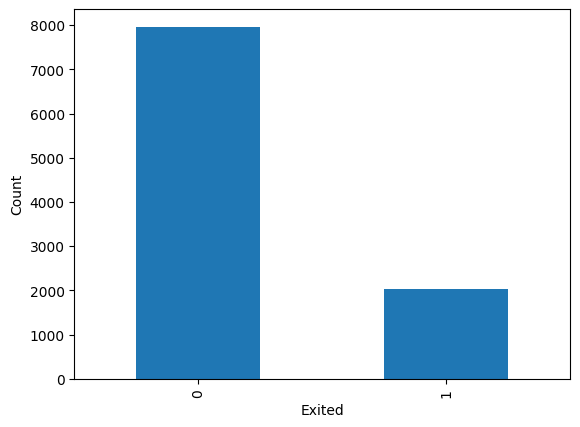

In [6]:
plt.xlabel('Exited')
plt.ylabel('Count')
df['Exited'].value_counts().plot.bar()
plt.show()

In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [9]:
# Convert the categorical variables to numerical values
from sklearn.preprocessing import StandardScaler, LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding on 'Gender' and 'Geography'
df['Gender'] = label_encoder.fit_transform(df['Gender'])  # Female=0, Male=1
df['Geography'] = label_encoder.fit_transform(df['Geography'])  # France=0, Germany=1, Spain=2

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


## Model selection and data normalization

In [11]:
from sklearn.model_selection import train_test_split
# Separate the features and the target variables
X = df.drop('Exited', axis = 1) # Features
Y = df['Exited'] # Target

# Split the dataset into training and testing set
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2,random_state=0)

# Normalize the dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [13]:
model = Sequential()

#First hidden layer
model.add(Dense(activation='relu', units=32, input_dim=X_train.shape[1]))  
model.add(Dropout(0.5))  

# Second hidden layer
model.add(Dense(activation='relu', units=16))  
# Output layer for binary classification
model.add(Dense(activation='sigmoid', units=1))  

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



In [20]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, y_train, batch_size=32, epochs=50,validation_split = 0.1, verbose = 2,callbacks=[early_stop])

Epoch 1/50
225/225 - 1s - loss: 0.3531 - accuracy: 0.8569 - val_loss: 0.3465 - val_accuracy: 0.8637 - 1s/epoch - 5ms/step
Epoch 2/50
225/225 - 1s - loss: 0.3556 - accuracy: 0.8558 - val_loss: 0.3458 - val_accuracy: 0.8600 - 935ms/epoch - 4ms/step
Epoch 3/50
225/225 - 1s - loss: 0.3523 - accuracy: 0.8572 - val_loss: 0.3460 - val_accuracy: 0.8637 - 954ms/epoch - 4ms/step
Epoch 4/50
225/225 - 1s - loss: 0.3524 - accuracy: 0.8585 - val_loss: 0.3453 - val_accuracy: 0.8600 - 955ms/epoch - 4ms/step
Epoch 5/50
225/225 - 1s - loss: 0.3520 - accuracy: 0.8549 - val_loss: 0.3469 - val_accuracy: 0.8687 - 952ms/epoch - 4ms/step
Epoch 6/50
225/225 - 1s - loss: 0.3563 - accuracy: 0.8549 - val_loss: 0.3445 - val_accuracy: 0.8612 - 936ms/epoch - 4ms/step
Epoch 7/50
225/225 - 1s - loss: 0.3479 - accuracy: 0.8583 - val_loss: 0.3450 - val_accuracy: 0.8662 - 942ms/epoch - 4ms/step
Epoch 8/50
225/225 - 1s - loss: 0.3520 - accuracy: 0.8553 - val_loss: 0.3450 - val_accuracy: 0.8575 - 938ms/epoch - 4ms/step
Epo

In [21]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5) # to convert the probabilistic values to True or False
y_pred

63/63 [==============================] - 0s 3ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

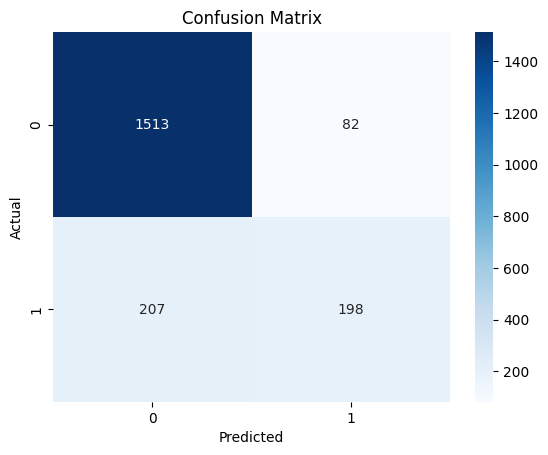

Accuracy Score: 0.8555


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)


# Create a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print the results
print("Accuracy Score:", accuracy)
